In [55]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [56]:
#fetching open weather api

API_KEY = "bb9ec3e85102a1a5dd5700134da3a8f0"
BASE_URL = "http://api.openweathermap.org/data/2.5/weather"


In [58]:
#list cities for real time data

cities=['london','new york','paris','tokyo','mumbai']

In [ ]:
#function to get weather for each city

def get_weather_data(cities,api_key):
    base_url="http://api.openweathermap.org/data/2.5/weather"
    data=[]  # we create a list to add data

    for city in cities:
        params = {
            'q': city,
            'appid': api_key,
            'units': 'metric'  #This is for celsius 
        }
        response = requests.get(base_url, params=params)
        weather = response.json()
        
        if response.status_code==200: #for valid  process

            city_data={
                'City':city,
                'Temperature':weather['main']['temp'],
                'Humidity':weather['main']['humidity'],
                'Wind speed':weather['wind']['speed'],
                'Time':datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                'Weather condition':weather['weather'][0]['description']
                }
            data.append(city_data)
        else:
            print("could not fetch weather data")
            
           


    df=pd.DataFrame(data)
    return df

   



In [60]:
# load from data frame 
 
df = get_weather_data(cities, API_KEY)
print(df)




       City  Temperature  Humidity  Wind speed                 Time  \
0    london         7.49        81        3.09  2024-11-15 22:34:14   
1  new york        11.70        44        6.17  2024-11-15 22:34:14   
2     paris         9.48        72        2.06  2024-11-15 22:34:15   
3     tokyo        16.12        71        5.03  2024-11-15 22:34:15   
4    mumbai        28.99        61        2.57  2024-11-15 22:34:15   

  Weather condition  
0     broken clouds  
1         clear sky  
2   overcast clouds  
3   overcast clouds  
4              haze  


In [62]:
#avg temp
avg_temp=df['Temperature'].mean()
avg_humidity=df['Humidity'].mean()

print("Average temperature is ",avg_temp,"C")
print("Humdity is ",avg_humidity)

Average temperature is  14.756 C
Humdity is  65.8


C:\Users\Ved\AppData\Local\Temp\ipykernel_25160\3021310046.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['City'],y=df['Temperature'],palette='Blues')


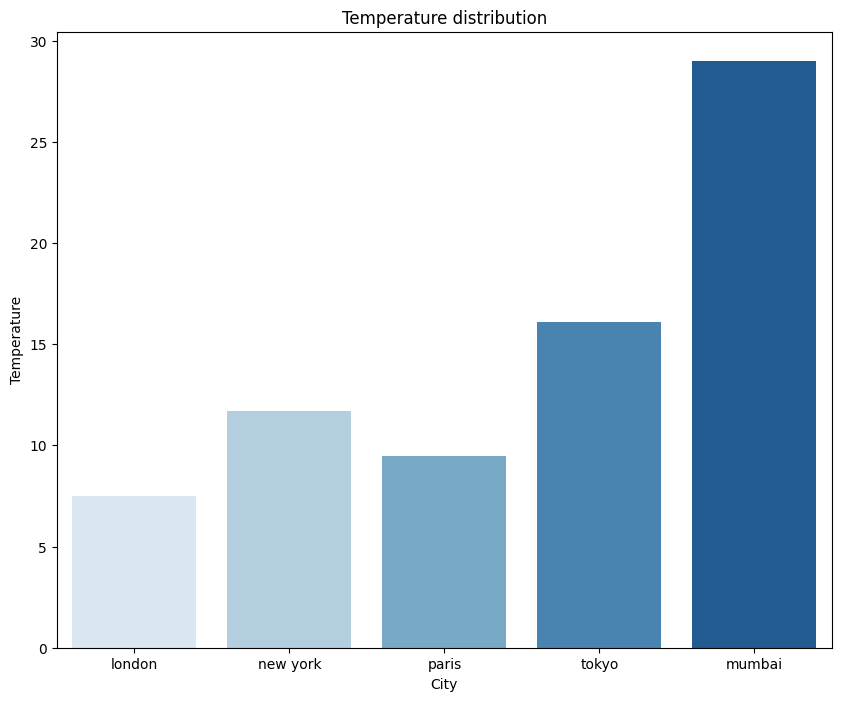

In [63]:
#visualisation

plt.figure(figsize=(10,8))

sns.barplot(x=df['City'],y=df['Temperature'],palette='Blues')
plt.xlabel("City")
plt.ylabel('Temperature')
plt.title('Temperature distribution')
plt.show()


In [64]:
print(df.describe())

       Temperature   Humidity  Wind speed
count     5.000000   5.000000      5.0000
mean     14.756000  65.800000      3.7840
std       8.579588  14.096099      1.7445
min       7.490000  44.000000      2.0600
25%       9.480000  61.000000      2.5700
50%      11.700000  71.000000      3.0900
75%      16.120000  72.000000      5.0300
max      28.990000  81.000000      6.1700


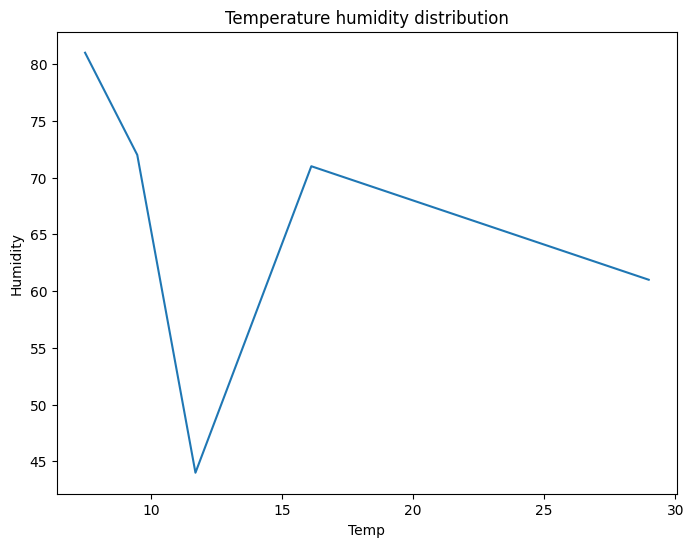

In [65]:
#line plot
plt.figure(figsize=(8,6))

sns.lineplot(data=df,x='Temperature',y='Humidity')
plt.xlabel("Temp")
plt.ylabel("Humidity")
plt.title('Temperature humidity distribution')
plt.show()


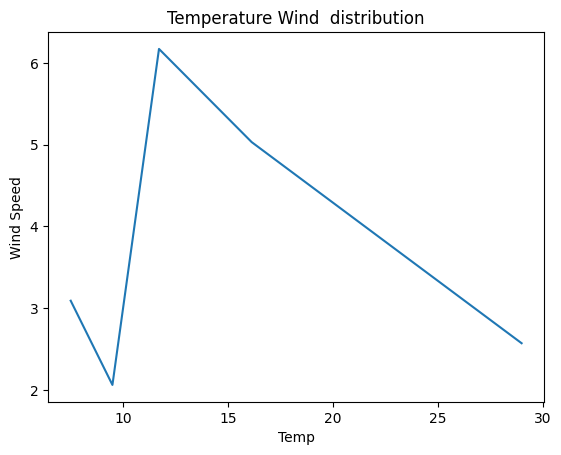

In [66]:
sns.lineplot(data=df,x='Temperature',y='Wind speed')
plt.xlabel("Temp")
plt.ylabel("Wind Speed")
plt.title('Temperature Wind  distribution')
plt.show()


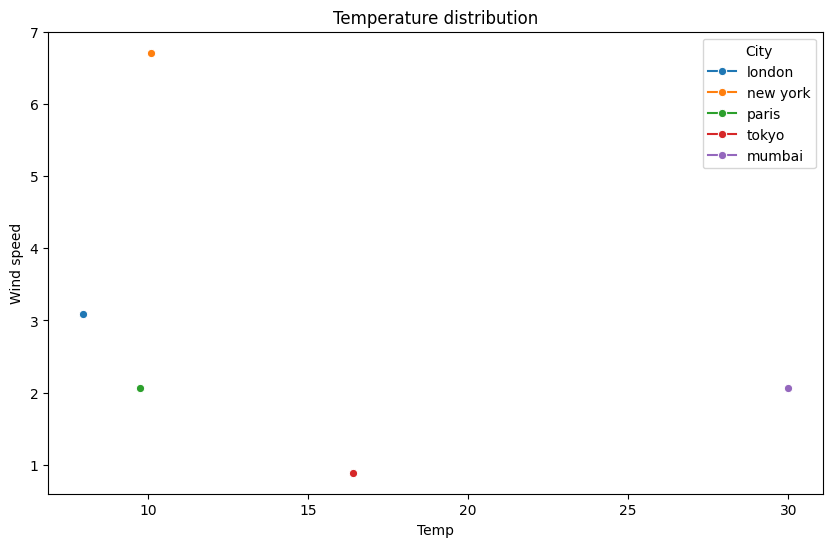

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Temperature', y='Wind speed', hue='City',marker='o')  

plt.xlabel("Temp")
plt.ylabel("Wind speed")
plt.title('Temperature distribution')
plt.show()

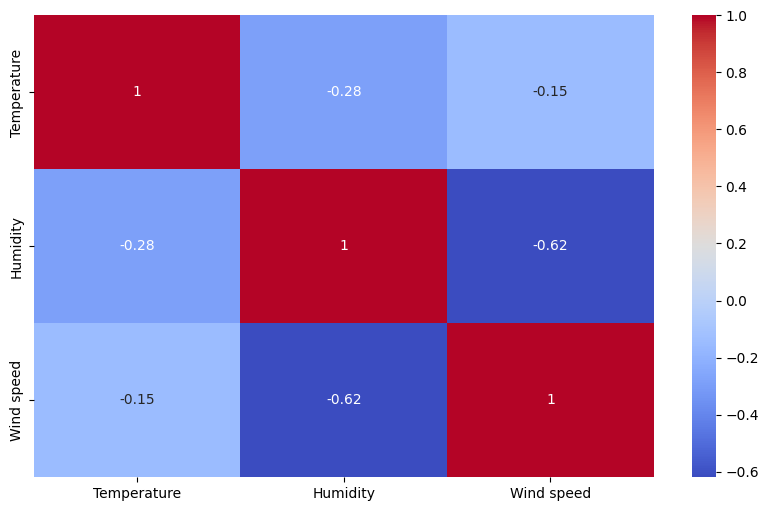

In [68]:
# correlation

plt.figure(figsize=(10,6))
correlation=df[['Temperature','Humidity','Wind speed']].corr()
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.show()